# GLP1 Cohort Body Mass Analysis — Full Pipeline

**Data source:** `MouseWeight_HFD_GLP1_June2025_CohortD.xlsx` (Cohort D, all `HFD&GLP_1` mice)

**Scope:** 29 mice. All phases covered:
- **Pre-GLP1 baseline** (June 2, 2025 — ~4 months of HFD feeding)
- **On-GLP1** (Oct 1 – Dec 1, 2025 — 9 weeks of semaglutide dosing)
- **Post-GLP1** (Dec 1–12, 2025 — brief washout tail)

**Analysis pipeline:**
1. Data construction and quality check
2. Whole-cohort trajectory (all three phases, starting from baseline = 100%)
3. Sex effect on weight trajectory and phase metrics
4. Genotype (E22/E33/E44) effect on weight trajectory and phase metrics
5. Genotype × Sex interaction
6. **Per-phase covariate analysis**: slope and % change for each of the three phases (Pre/On/Post-GLP1), displayed on a unified timeline
7. **Linear Mixed Effects model** (random intercept per mouse) — On-GLP1 and Post-GLP1 phases
8. **Stratified genotype analysis by sex** — effect sizes (Cohen's d), 95% CIs, post-hoc pairwise comparisons; all results saved to Excel

**Genotype convention:** APOE22HN → E22, APOE33HN → E33, APOE44HN → E44

**Trajectory plots:** weight expressed as **% of each animal's own GLP1 Day 1 weight** (= 100% at October 2, 2025, the first on-treatment measurement). This means all curves start from the same 100% reference point regardless of baseline body weight differences, so the trajectory reflects the *pure GLP1-driven change* without confounding from pre-existing weight differences between genotypes or sexes.

In [1]:
import pandas as pd
import numpy as np
import re
import math
from scipy import stats
from itertools import combinations
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

DATA_PATH = 'MouseWeight_HFD_GLP1_June2025_CohortD.xlsx'

GLP1_START = pd.Timestamp('2025-10-01')
GLP1_END   = pd.Timestamp('2025-12-01')
BASELINE_DATE = pd.Timestamp('2025-06-02')

GROUP_PAL    = {'Pre-GLP1':'#888888', 'On-GLP1':'#2C8C53', 'Post-GLP1':'#C0563D'}
SEX_PAL      = {'Male':'#4472C4', 'Female':'#DD8452'}
GENO_PAL     = {'E22':'#4472C4', 'E33':'#55A868', 'E44':'#C44E52'}

def map_genotype(g):
    return {'APOE22HN':'E22','APOE33HN':'E33','APOE44HN':'E44'}.get(g, g)

def parse_date_col(c):
    m = re.search(r'(\d{6})$', c)
    s = m.group(1); mm,dd,yy = s[:2], s[2:4], s[4:]
    return pd.Timestamp(f'20{yy}-{mm}-{dd}')

print('Setup complete')

Setup complete


## 1. Data Construction

In [2]:
xl = pd.ExcelFile(DATA_PATH)
sema = pd.read_excel(xl, sheet_name='Sema')
week4 = pd.read_excel(xl, sheet_name='week4')

sema['Genotype3'] = sema['Genotype'].map(map_genotype)
sema['Sex_full']  = sema['Sex'].map({'M':'Male','F':'Female'})
sema['GLP_1Start'] = pd.to_datetime(sema['GLP_1Start'])
sema['GLP_1End']   = pd.to_datetime(sema['GLP_1End'])
sema['HFD_Start']  = pd.to_datetime(sema['HFD_Start'])

# Baseline: June 2 2025 (week4 sheet)
baseline = week4[['Animal_ID','Weight_g_060225']].rename(columns={'Weight_g_060225':'Weight_g'})
baseline['Date'] = BASELINE_DATE

# On-GLP1 / Post-GLP1 measurements from Sema sheet
weight_cols = [c for c in sema.columns if 'Weight' in c and 'Animal' in c]
rows = []
for _, r in sema.iterrows():
    for c in weight_cols:
        v = r[c]
        if pd.notna(v):
            rows.append({'Animal_ID': r['Animal_ID'], 'Date': parse_date_col(c), 'Weight_g': float(v)})

long_df = pd.concat([baseline[['Animal_ID','Date','Weight_g']].dropna(), pd.DataFrame(rows)], ignore_index=True)
long_df = long_df.merge(sema[['Animal_ID','Sex_full','Genotype3']], on='Animal_ID', how='left')
long_df.sort_values(['Animal_ID','Date'], inplace=True)

# Phase labels
long_df['Phase'] = long_df['Date'].apply(
    lambda d: 'Pre-GLP1' if d < GLP1_START else ('Post-GLP1' if d > GLP1_END else 'On-GLP1'))

# Weight as % of each animal's own GLP1 Day 1 weight (first On-GLP1 measurement = 100%)
# This removes the effect of pre-existing body weight differences at GLP1 start,
# so all animals start at 100% and trajectories reflect pure GLP1-period change.
first_onglp1 = long_df[long_df['Phase']=='On-GLP1'].sort_values('Date').groupby('Animal_ID')['Weight_g'].first()
long_df['Weight_pct'] = long_df.apply(lambda r: r['Weight_g'] / first_onglp1[r['Animal_ID']] * 100, axis=1)

# Days since GLP1 start (for mixed model)
long_df['Days_since_GLP1start'] = (long_df['Date'] - GLP1_START).dt.days

print(f"Long table: {long_df.shape[0]} rows, {long_df['Animal_ID'].nunique()} mice")
print(long_df['Phase'].value_counts())
first_day = long_df[long_df['Phase']=='On-GLP1'].sort_values('Date').groupby('Animal_ID').first()
print("\nGLP1 Day-1 mean % (should be 100.0):", first_day['Weight_pct'].mean().round(2))
long_df.head()

Long table: 982 rows, 29 mice
Phase
On-GLP1      870
Post-GLP1     83
Pre-GLP1      29
Name: count, dtype: int64

GLP1 Day-1 mean % (should be 100.0): 100.0


/opt/miniconda3/lib/python3.13/site-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: week8!$A:$O.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")


,Animal_ID,Date,Weight_g,Sex_full,Genotype3,Phase,Weight_pct,Days_since_GLP1start
0,250530_1,2025-06-02,31.0000,Male,E22,Pre-GLP1,67.3913,-121
29,250530_1,2025-10-02,46.0000,Male,E22,On-GLP1,100.0000,1
30,250530_1,2025-10-06,46.0000,Male,E22,On-GLP1,100.0000,5
31,250530_1,2025-10-08,46.0000,Male,E22,On-GLP1,100.0000,7
32,250530_1,2025-10-10,43.0000,Male,E22,On-GLP1,93.4783,9


In [3]:
# Per-animal per-phase summary: slope (%/day) and % change (first → last)
def phase_summary(data):
    rows = []
    for (aid, phase), g in data.groupby(['Animal_ID','Phase']):
        g = g.sort_values('Date')
        meta = g[['Sex_full','Genotype3']].iloc[0]
        if len(g) >= 2:
            t = (g['Date'] - g['Date'].min()).dt.days.values.astype(float)
            y = g['Weight_pct'].values
            if t.max() > 0:
                slope, *_ = stats.linregress(t, y)
            else:
                slope = np.nan
            pct_chg = y[-1] - y[0]
        else:
            slope = pct_chg = np.nan
        rows.append({'Animal_ID':aid,'Phase':phase,'Sex_full':meta['Sex_full'],
                     'Genotype3':meta['Genotype3'],'slope':slope,'pct_change':pct_chg})
    return pd.DataFrame(rows)

pm_df = phase_summary(long_df)
print("Phase summary shape:", pm_df.shape)
print(pm_df.groupby('Phase')[['slope','pct_change']].describe().round(3))

Phase summary shape: (86, 6)
            slope                                                       pct_change                                                           
            count    mean    std     min     25%     50%     75%    max      count     mean    std      min      25%      50%      75%    max
Phase                                                                                                                                        
On-GLP1   29.0000 -0.1850 0.1360 -0.5150 -0.2360 -0.1880 -0.0930 0.0730    29.0000 -15.0650 9.7730 -37.7360 -21.0530 -13.3330 -10.6380 1.8180
Post-GLP1 28.0000 -1.5520 1.8420 -9.0000 -2.1390 -1.4390 -0.5210 1.0640    28.0000  -5.5660 5.1130 -18.0000  -8.5570  -5.7570  -2.0830 4.2550
Pre-GLP1   0.0000     NaN    NaN     NaN     NaN     NaN     NaN    NaN     0.0000      NaN    NaN      NaN      NaN      NaN      NaN    NaN


## 2. Whole-Cohort Trajectory (GLP1 Day 1 = 100%)

Each animal's weight is expressed as **% of its own first On-GLP1 measurement (Oct 2, 2025 = 100%)**. The pre-GLP1 baseline (June 2) therefore appears **below 100%** (~58–61%) because mice were lighter then — it shows how much weight was gained on HFD before treatment started. The On-GLP1 window shows weight loss from 100% downward.

/var/folders/12/z47y_64x4js0kzq69526v83m0000gn/T/ipykernel_6049/731176490.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pm_plot, x='Phase', y='pct_change', order=phase_order,


On-GLP1: mean=-15.06%, t=-8.30, p=0.0000 ***
Post-GLP1: mean=-5.57%, t=-5.76, p=0.0000 ***


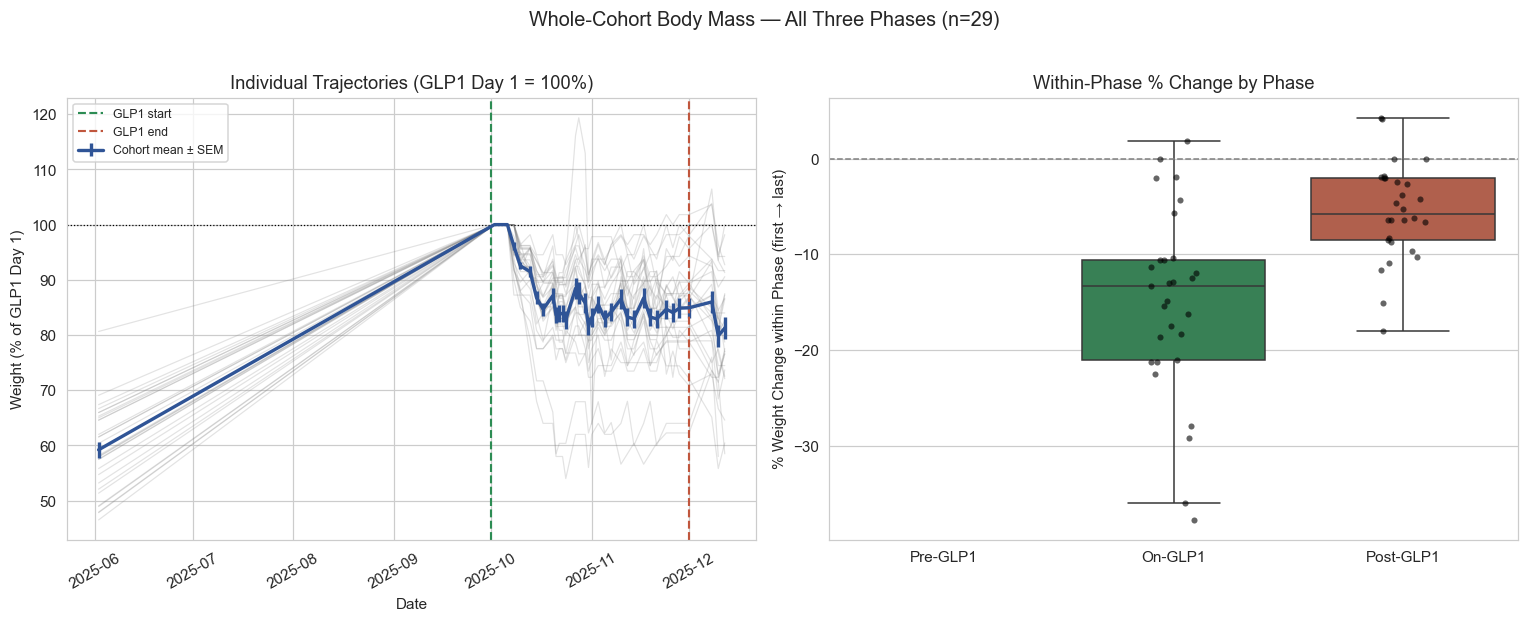

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for aid, sub in long_df.groupby('Animal_ID'):
    sub = sub.sort_values('Date')
    axes[0].plot(sub['Date'], sub['Weight_pct'], color='gray', alpha=0.22, linewidth=0.8)
cohort_avg = long_df.groupby('Date')['Weight_pct'].agg(['mean','sem']).reset_index()
axes[0].errorbar(cohort_avg['Date'], cohort_avg['mean'], yerr=cohort_avg['sem'],
                 color='#2F5496', linewidth=2.2, label='Cohort mean \u00b1 SEM')
axes[0].axhline(100, color='black', linewidth=0.8, linestyle=':')
axes[0].axvline(GLP1_START, color='#2C8C53', linestyle='--', linewidth=1.4, label='GLP1 start')
axes[0].axvline(GLP1_END,   color='#C0563D', linestyle='--', linewidth=1.4, label='GLP1 end')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Weight (% of GLP1 Day 1)')
axes[0].set_title('Individual Trajectories (GLP1 Day 1 = 100%)')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=30)

# Phase-level boxplot
phase_order = ['Pre-GLP1','On-GLP1','Post-GLP1']
pm_plot = pm_df.dropna(subset=['pct_change'])
sns.boxplot(data=pm_plot, x='Phase', y='pct_change', order=phase_order,
            palette=GROUP_PAL, ax=axes[1], showfliers=False)
sns.stripplot(data=pm_plot, x='Phase', y='pct_change', order=phase_order,
              color='black', size=4, alpha=0.6, ax=axes[1])
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('')
axes[1].set_ylabel('% Weight Change within Phase (first \u2192 last)')
axes[1].set_title('Within-Phase % Change by Phase')

for ph in phase_order:
    vals = pm_df[pm_df['Phase']==ph]['pct_change'].dropna()
    if len(vals) >= 3:
        t, p = stats.ttest_1samp(vals, 0)
        sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'n.s.'))
        print(f"{ph}: mean={vals.mean():.2f}%, t={t:.2f}, p={p:.4f} {sig}")

plt.suptitle('Whole-Cohort Body Mass — All Three Phases (n=29)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('fig01_cohort_trajectory.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Sex Effect on Weight Trajectory and Phase Metrics

/var/folders/12/z47y_64x4js0kzq69526v83m0000gn/T/ipykernel_6049/2282299036.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Sex_full', y=metric, palette=SEX_PAL, ax=ax, showfliers=False)
/var/folders/12/z47y_64x4js0kzq69526v83m0000gn/T/ipykernel_6049/2282299036.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Sex_full', y=metric, palette=SEX_PAL, ax=ax, showfliers=False)


slope: Male=-0.109, Female=-0.247, U=162.0, p=0.0117, Cohen's d=1.170
pct_change: Male=-9.256, Female=-19.784, U=169.0, p=0.0047, Cohen's d=1.262


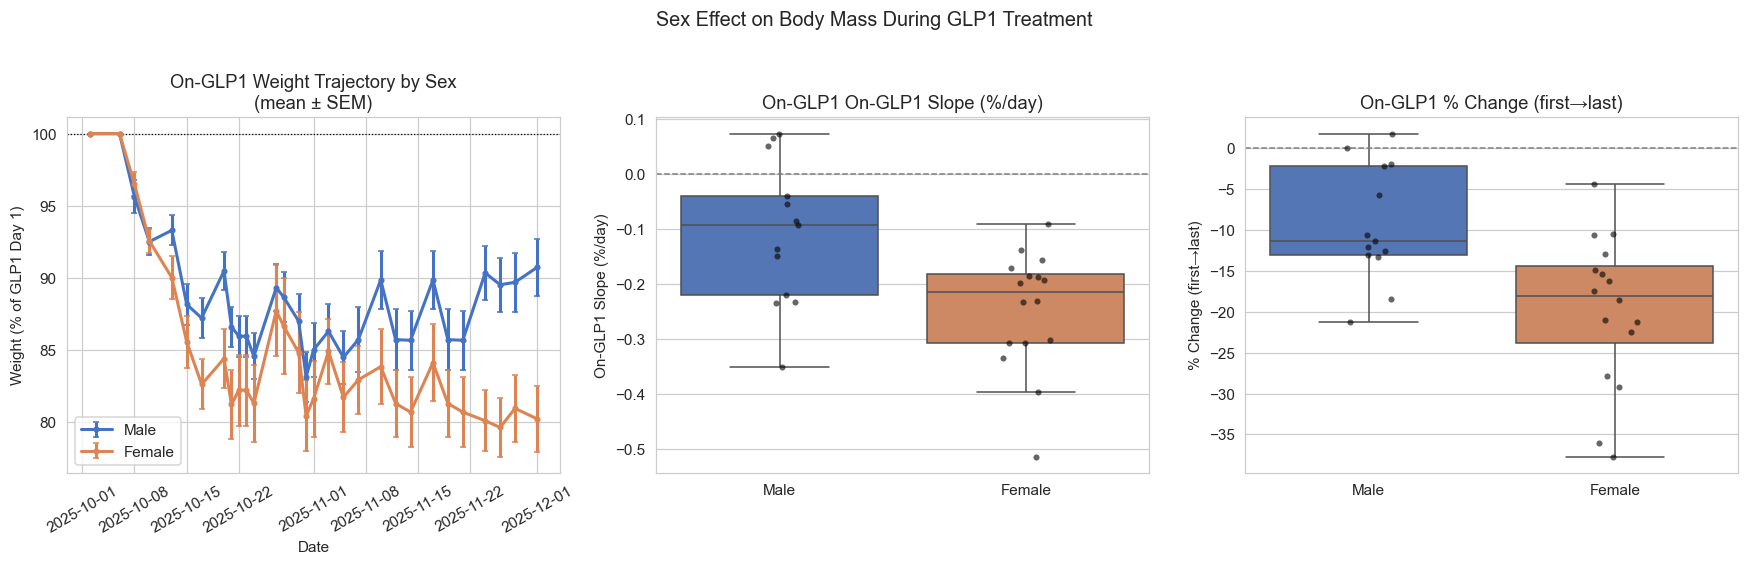

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: On-GLP1 trajectory by sex
ax = axes[0]
for sex, color in SEX_PAL.items():
    sub = long_df[(long_df['Sex_full']==sex) & (long_df['Phase']=='On-GLP1')]
    stat = sub.groupby('Date')['Weight_pct'].agg(['mean','sem']).reset_index()
    ax.errorbar(stat['Date'], stat['mean'], yerr=stat['sem'], marker='o', markersize=3,
                capsize=2, color=color, linewidth=2, label=sex)
ax.axhline(100, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel('Date')
ax.set_ylabel('Weight (% of GLP1 Day 1)')
ax.set_title('On-GLP1 Weight Trajectory by Sex\n(mean \u00b1 SEM)')
ax.legend()
ax.tick_params(axis='x', rotation=30)

# Panels 2-3: slope and pct_change boxplots, all phases
for i, (metric, title) in enumerate([('slope','On-GLP1 Slope (%/day)'),('pct_change','% Change (first\u2192last)')]):
    ax = axes[i+1]
    sub = pm_df[pm_df['Phase']=='On-GLP1'].dropna(subset=[metric])
    sns.boxplot(data=sub, x='Sex_full', y=metric, palette=SEX_PAL, ax=ax, showfliers=False)
    sns.stripplot(data=sub, x='Sex_full', y=metric, color='black', size=4, alpha=0.6, ax=ax)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('')
    ax.set_title(f'On-GLP1 {title}')
    m = sub[sub['Sex_full']=='Male'][metric].dropna()
    f = sub[sub['Sex_full']=='Female'][metric].dropna()
    if len(m)>0 and len(f)>0:
        u, p = stats.mannwhitneyu(m, f, alternative='two-sided')
        d = (m.mean()-f.mean())/np.sqrt(((len(m)-1)*m.var(ddof=1)+(len(f)-1)*f.var(ddof=1))/(len(m)+len(f)-2))
        print(f"{metric}: Male={m.mean():.3f}, Female={f.mean():.3f}, U={u:.1f}, p={p:.4f}, Cohen\'s d={d:.3f}")
    ax.set_ylabel(title)

plt.suptitle('Sex Effect on Body Mass During GLP1 Treatment', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('fig02_sex_effect.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Genotype Effect on Weight Trajectory and Phase Metrics

/var/folders/12/z47y_64x4js0kzq69526v83m0000gn/T/ipykernel_6049/322217212.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Genotype3', y=metric, order=geno_order, palette=GENO_PAL, ax=ax, showfliers=False)
/var/folders/12/z47y_64x4js0kzq69526v83m0000gn/T/ipykernel_6049/322217212.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Genotype3', y=metric, order=geno_order, palette=GENO_PAL, ax=ax, showfliers=False)


slope: Kruskal H=1.435, p=0.4880
pct_change: Kruskal H=3.802, p=0.1494


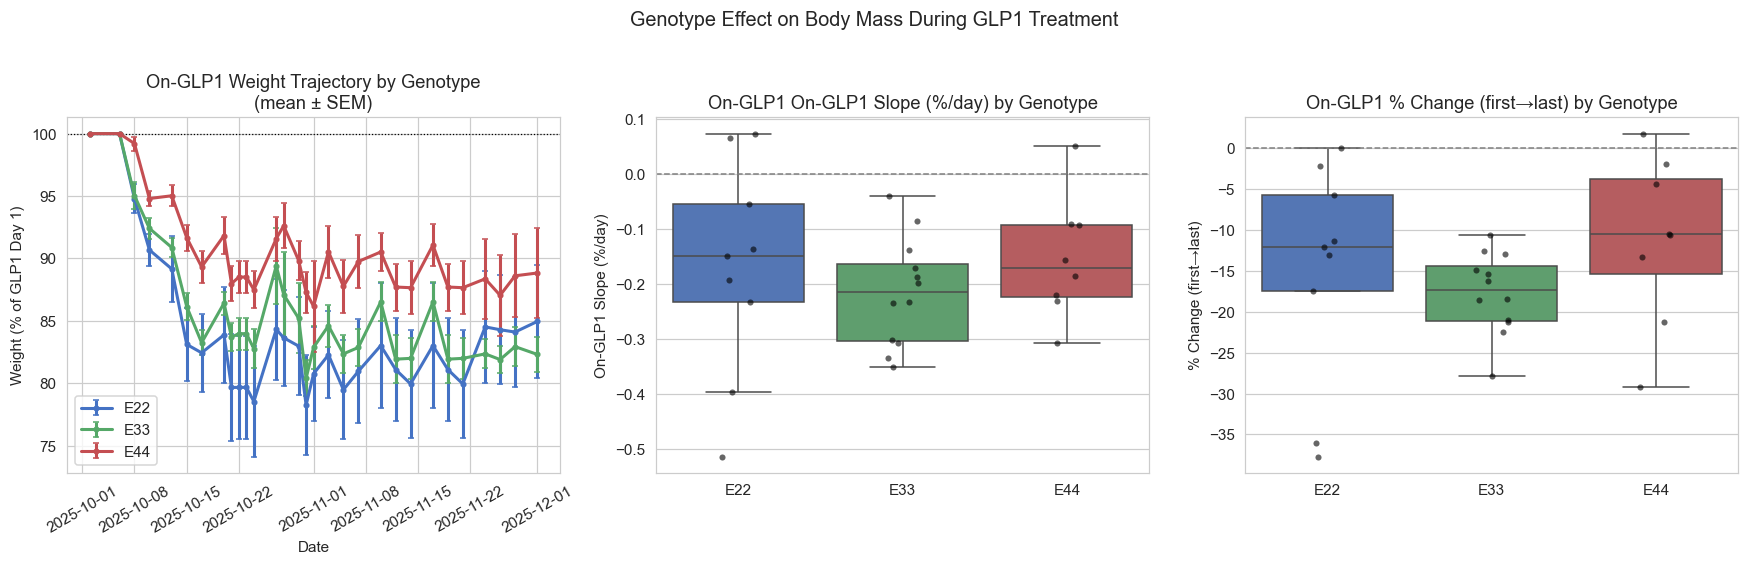

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: On-GLP1 trajectory by genotype
ax = axes[0]
for geno, color in GENO_PAL.items():
    sub = long_df[(long_df['Genotype3']==geno) & (long_df['Phase']=='On-GLP1')]
    stat = sub.groupby('Date')['Weight_pct'].agg(['mean','sem']).reset_index()
    ax.errorbar(stat['Date'], stat['mean'], yerr=stat['sem'], marker='o', markersize=3,
                capsize=2, color=color, linewidth=2, label=geno)
ax.axhline(100, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel('Date')
ax.set_ylabel('Weight (% of GLP1 Day 1)')
ax.set_title('On-GLP1 Weight Trajectory by Genotype\n(mean \u00b1 SEM)')
ax.legend()
ax.tick_params(axis='x', rotation=30)

# Panels 2-3: genotype boxplots
geno_order = ['E22','E33','E44']
for i, (metric, title) in enumerate([('slope','On-GLP1 Slope (%/day)'),('pct_change','% Change (first\u2192last)')]):
    ax = axes[i+1]
    sub = pm_df[pm_df['Phase']=='On-GLP1'].dropna(subset=[metric])
    sns.boxplot(data=sub, x='Genotype3', y=metric, order=geno_order, palette=GENO_PAL, ax=ax, showfliers=False)
    sns.stripplot(data=sub, x='Genotype3', y=metric, order=geno_order, color='black', size=4, alpha=0.6, ax=ax)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    groups = [sub[sub['Genotype3']==g][metric].dropna() for g in geno_order]
    groups = [g for g in groups if len(g)>0]
    if len(groups)>=2:
        h, p = stats.kruskal(*groups)
        print(f"{metric}: Kruskal H={h:.3f}, p={p:.4f}")
    ax.set_xlabel('')
    ax.set_title(f'On-GLP1 {title} by Genotype')
    ax.set_ylabel(title)

plt.suptitle('Genotype Effect on Body Mass During GLP1 Treatment', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('fig03_genotype_effect.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Genotype × Sex Interaction

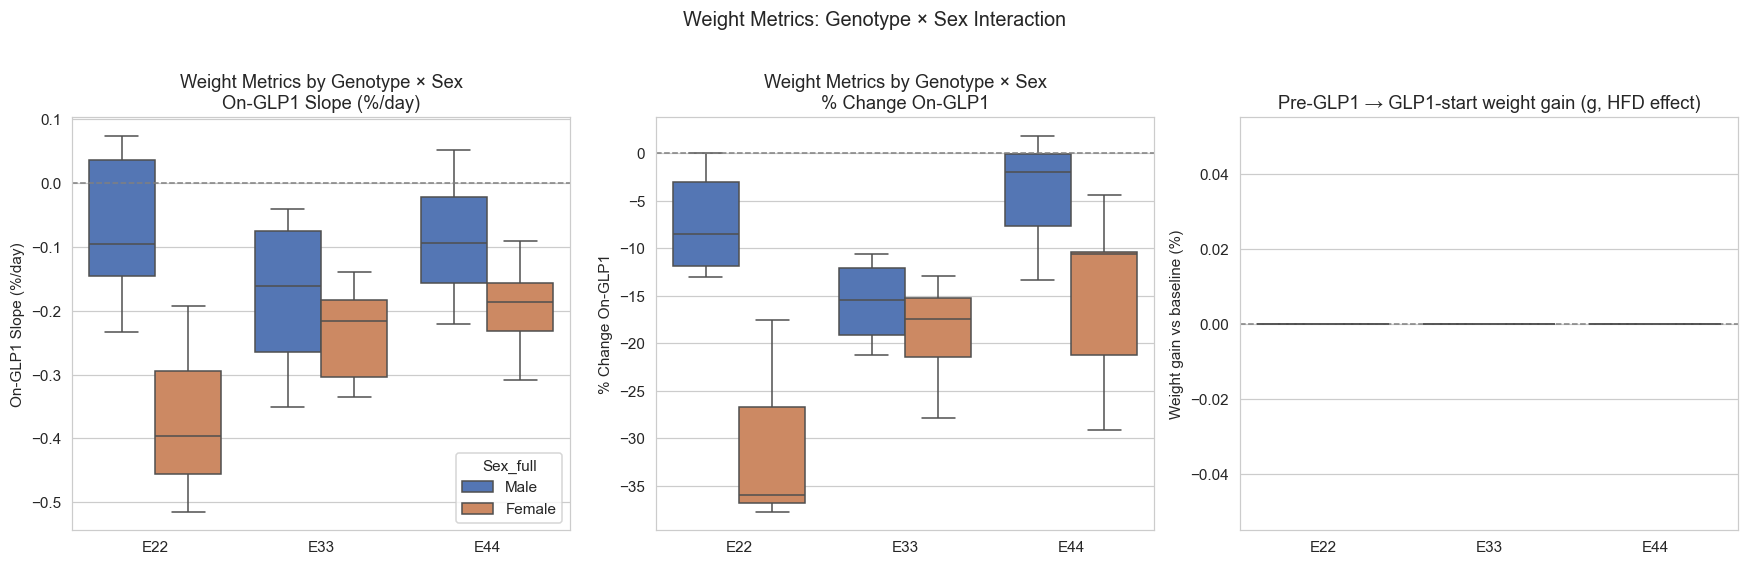

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
geno_order = ['E22','E33','E44']
sub = pm_df[pm_df['Phase']=='On-GLP1'].dropna(subset=['slope','pct_change'])

for i, (metric, title) in enumerate([
    ('slope','On-GLP1 Slope (%/day)'),
    ('pct_change','% Change On-GLP1'),
    ('pct_change','HFD Gain (Pre-GLP1 % change)')
]):
    ax = axes[i]
    if i == 2:
        sub2 = pm_df[pm_df['Phase']=='Pre-GLP1'].dropna(subset=['pct_change'])
        # Compute as first On-GLP1 measurement - baseline for each mouse
        first_on = long_df[long_df['Phase']=='On-GLP1'].sort_values('Date').groupby('Animal_ID').first().reset_index()
        first_on['hfd_gain_pct'] = 0.0  # In GLP1-day-1 rebased units, Day 1 IS 100% for all mice; HFD gain is now shown via Pre-GLP1 values
        sub2 = first_on
        sns.boxplot(data=sub2, x='Genotype3', y='hfd_gain_pct', hue='Sex_full', order=geno_order,
                    palette=SEX_PAL, ax=ax)
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_ylabel('Weight gain vs baseline (%)')
        ax.set_title('Pre-GLP1 \u2192 GLP1-start weight gain (g, HFD effect)')
    else:
        sns.boxplot(data=sub, x='Genotype3', y=metric, hue='Sex_full', order=geno_order,
                    palette=SEX_PAL, ax=ax)
        ax.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax.set_ylabel(title)
        ax.set_title(f'Weight Metrics by Genotype \u00d7 Sex\n{title}')
    ax.set_xlabel('')
    if i != 0:
        ax.get_legend().remove()

plt.suptitle('Weight Metrics: Genotype \u00d7 Sex Interaction', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('fig04_geno_sex_interaction.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Per-Phase Covariate Analysis (Unified Timeline)

For each of the three phases (Pre-GLP1, On-GLP1, Post-GLP1), two metrics are shown:
- **Slope** (%/day within that phase)
- **% Change** (first to last measurement within that phase)

Panels are arranged left-to-right chronologically (Pre → On → Post), with each phase split into slope (top) and % change (bottom), separately by Sex and by Genotype.

/var/folders/12/z47y_64x4js0kzq69526v83m0000gn/T/ipykernel_6049/786764046.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Sex_full', y='slope', palette=SEX_PAL, ax=ax, showfliers=False)
/var/folders/12/z47y_64x4js0kzq69526v83m0000gn/T/ipykernel_6049/786764046.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Sex_full', y='pct_change', palette=SEX_PAL, ax=ax, showfliers=False)
/var/folders/12/z47y_64x4js0kzq69526v83m0000gn/T/ipykernel_6049/786764046.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=su

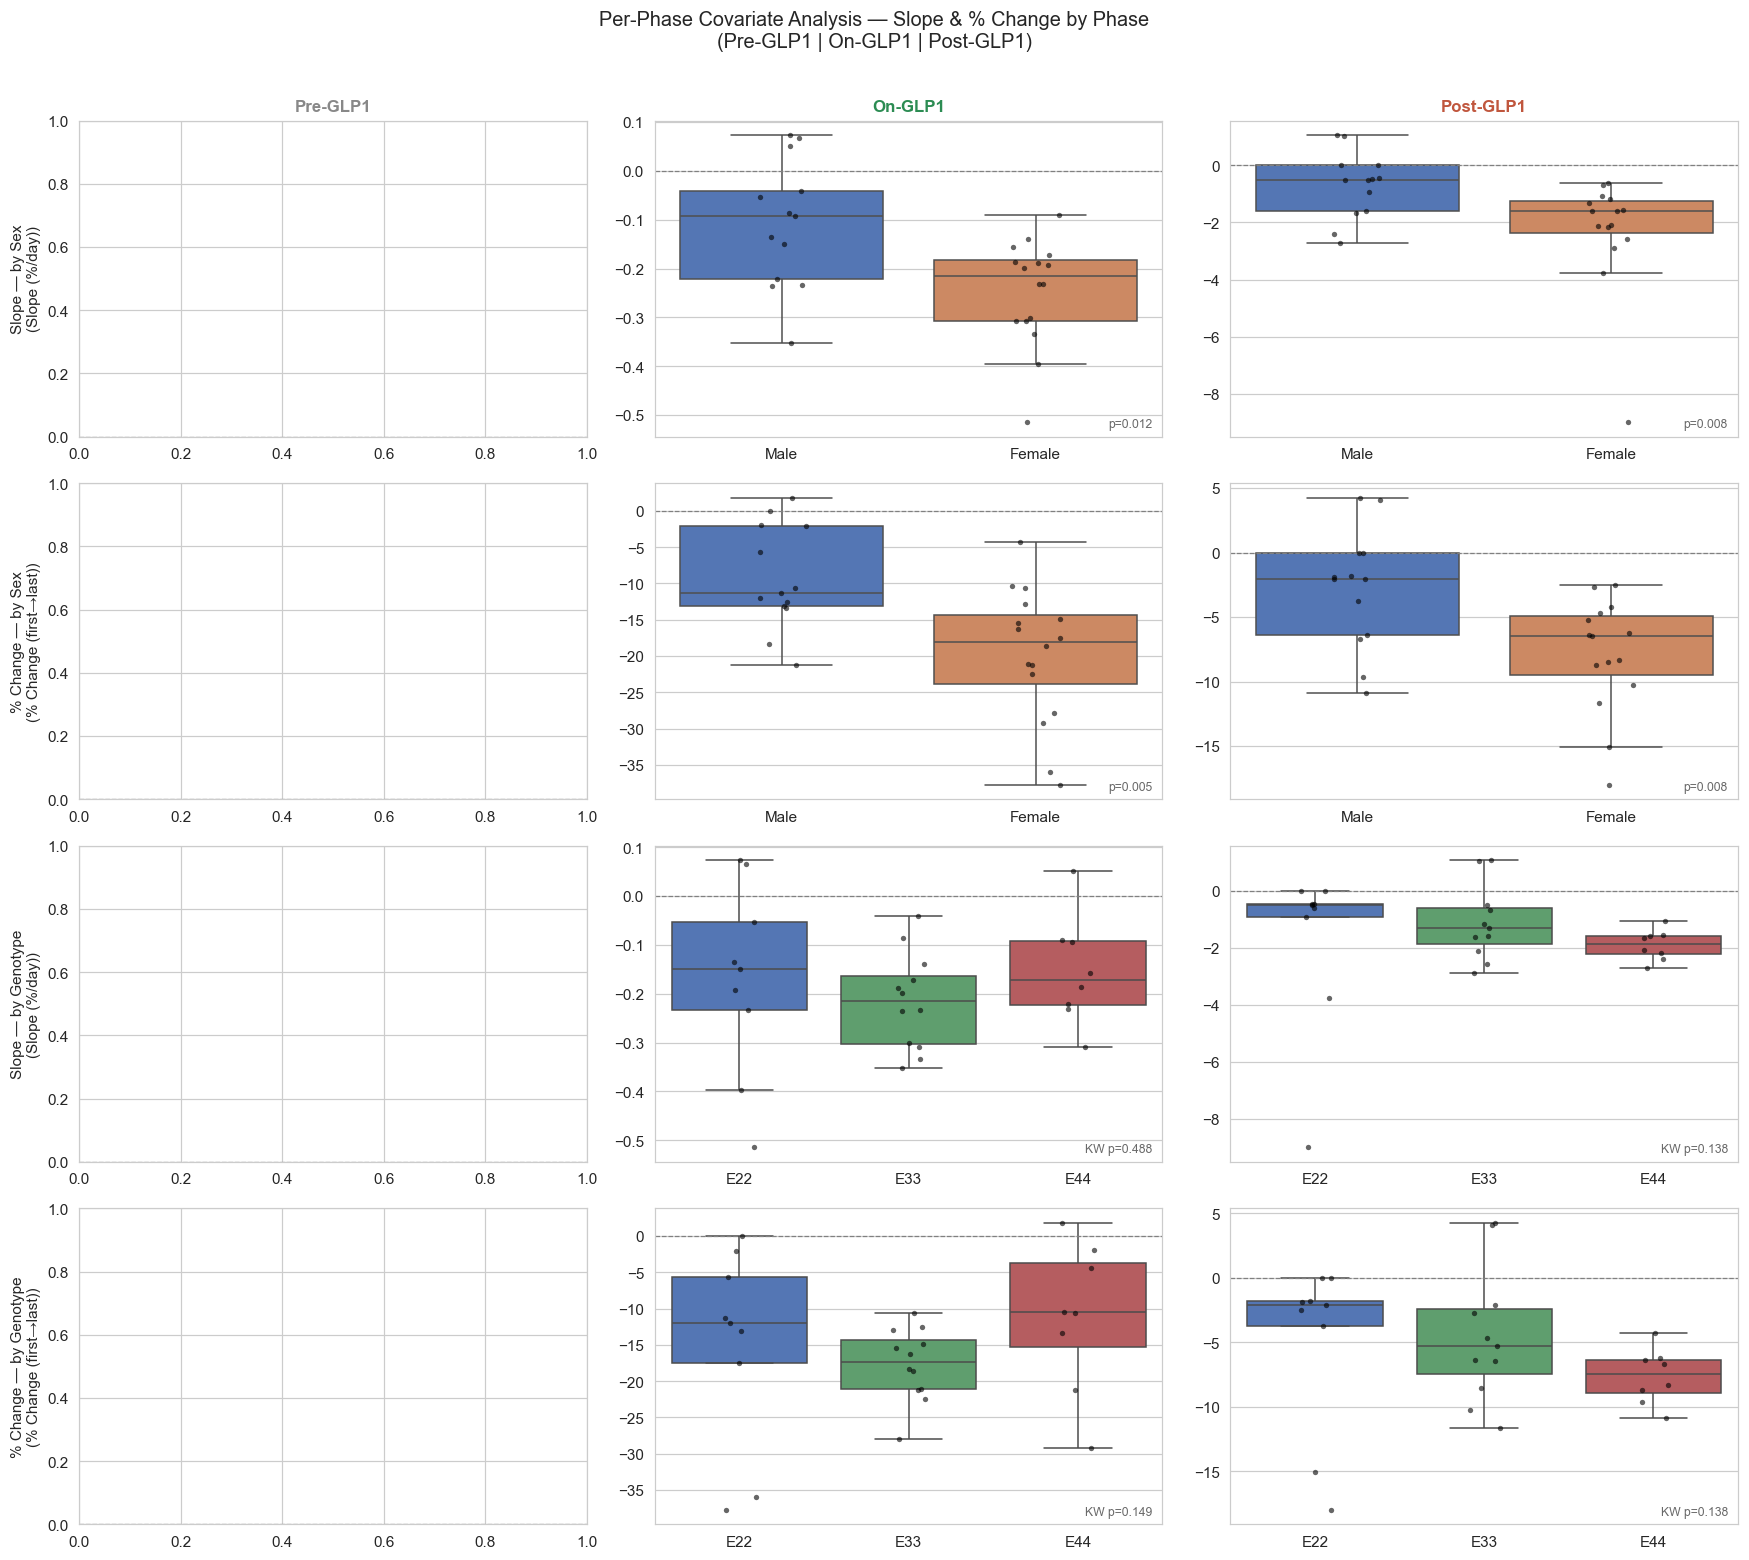

In [8]:
phase_order = ['Pre-GLP1', 'On-GLP1', 'Post-GLP1']
phase_colors = {'Pre-GLP1':'#888888', 'On-GLP1':'#2C8C53', 'Post-GLP1':'#C0563D'}
geno_order = ['E22','E33','E44']

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
fig.suptitle('Per-Phase Covariate Analysis — Slope & % Change by Phase\n(Pre-GLP1 | On-GLP1 | Post-GLP1)', fontsize=13, y=1.01)

for col, phase in enumerate(phase_order):
    sub = pm_df[pm_df['Phase']==phase].dropna(subset=['slope','pct_change'])
    color = phase_colors[phase]

    # Row 0: slope by Sex
    ax = axes[0][col]
    sns.boxplot(data=sub, x='Sex_full', y='slope', palette=SEX_PAL, ax=ax, showfliers=False)
    sns.stripplot(data=sub, x='Sex_full', y='slope', color='black', size=3.5, alpha=0.6, ax=ax)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'{phase}', fontsize=11, color=color, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Slope (%/day)' if col==0 else '')
    m = sub[sub['Sex_full']=='Male']['slope'].dropna()
    f = sub[sub['Sex_full']=='Female']['slope'].dropna()
    if len(m)>0 and len(f)>0 and len(m)+len(f)>2:
        u,p = stats.mannwhitneyu(m,f,alternative='two-sided')
        ax.text(0.98,0.02,f'p={p:.3f}',transform=ax.transAxes,ha='right',va='bottom',fontsize=8,color='dimgray')

    # Row 1: pct_change by Sex
    ax = axes[1][col]
    sns.boxplot(data=sub, x='Sex_full', y='pct_change', palette=SEX_PAL, ax=ax, showfliers=False)
    sns.stripplot(data=sub, x='Sex_full', y='pct_change', color='black', size=3.5, alpha=0.6, ax=ax)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('')
    ax.set_ylabel('% Change (first\u2192last)' if col==0 else '')
    m = sub[sub['Sex_full']=='Male']['pct_change'].dropna()
    f = sub[sub['Sex_full']=='Female']['pct_change'].dropna()
    if len(m)>0 and len(f)>0 and len(m)+len(f)>2:
        u,p = stats.mannwhitneyu(m,f,alternative='two-sided')
        ax.text(0.98,0.02,f'p={p:.3f}',transform=ax.transAxes,ha='right',va='bottom',fontsize=8,color='dimgray')

    # Row 2: slope by Genotype
    ax = axes[2][col]
    sns.boxplot(data=sub, x='Genotype3', y='slope', order=geno_order, palette=GENO_PAL, ax=ax, showfliers=False)
    sns.stripplot(data=sub, x='Genotype3', y='slope', order=geno_order, color='black', size=3.5, alpha=0.6, ax=ax)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('')
    ax.set_ylabel('Slope (%/day)' if col==0 else '')
    grps = [sub[sub['Genotype3']==g]['slope'].dropna() for g in geno_order if len(sub[sub['Genotype3']==g])>0]
    if len(grps)>=2 and sum(len(g) for g in grps)>3:
        h,p = stats.kruskal(*grps)
        ax.text(0.98,0.02,f'KW p={p:.3f}',transform=ax.transAxes,ha='right',va='bottom',fontsize=8,color='dimgray')

    # Row 3: pct_change by Genotype
    ax = axes[3][col]
    sns.boxplot(data=sub, x='Genotype3', y='pct_change', order=geno_order, palette=GENO_PAL, ax=ax, showfliers=False)
    sns.stripplot(data=sub, x='Genotype3', y='pct_change', order=geno_order, color='black', size=3.5, alpha=0.6, ax=ax)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('')
    ax.set_ylabel('% Change (first\u2192last)' if col==0 else '')
    grps = [sub[sub['Genotype3']==g]['pct_change'].dropna() for g in geno_order if len(sub[sub['Genotype3']==g])>0]
    if len(grps)>=2 and sum(len(g) for g in grps)>3:
        h,p = stats.kruskal(*grps)
        ax.text(0.98,0.02,f'KW p={p:.3f}',transform=ax.transAxes,ha='right',va='bottom',fontsize=8,color='dimgray')

# Row labels
for row, label in enumerate(['Slope — by Sex','% Change — by Sex','Slope — by Genotype','% Change — by Genotype']):
    axes[row][0].set_ylabel(f'{label}\n({axes[row][0].get_ylabel()})')

plt.tight_layout()
plt.savefig('fig05_per_phase_covariate.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Linear Mixed Effects Model (Random Intercept per Mouse)

Since multiple measurements per mouse are not independent, a linear mixed effects model (LME) with a **random intercept per mouse** properly partitions variance between within-mouse measurement noise and between-mouse baseline differences.

Model: `Weight_pct ~ Days + (1 | Mouse)` (Weight_pct = % of each mouse's own GLP1 Day 1 weight)

The model is estimated via an **EM algorithm** (E-step: compute posterior random effects; M-step: update fixed effects and variance components). Fixed-effect estimates, SEs, 95% CIs, and p-values (approximate t-distribution with `n_obs − n_subjects − n_fixef + 1` degrees of freedom) are reported.

Run separately for **On-GLP1** and **Post-GLP1** phases, and for subgroups (Sex × Genotype) within the On-GLP1 phase.

In [9]:
def lme_random_intercept(data, y_col, time_col, subject_col, covariates=None, n_iter=80):
    """
    Simple linear mixed effects model: y ~ 1 + time [+ covariates] + (1|subject)
    Estimated via EM algorithm. Returns dict with fixed effects, SEs, CIs, p-values.
    """
    cols = [y_col, time_col, subject_col] + (covariates or [])
    sub = data[cols].dropna().copy()
    subjects = sub[subject_col].unique()
    n_subj = len(subjects)
    subj_idx = np.array([np.where(subjects==s)[0][0] for s in sub[subject_col]])
    
    t = sub[time_col].values.astype(float)
    y = sub[y_col].values.astype(float)
    X = np.column_stack([np.ones(len(y)), t])
    feat_names = ['Intercept', time_col]
    if covariates:
        for cov in covariates:
            X = np.column_stack([X, sub[cov].values])
            feat_names.append(cov)
    
    # Initialize
    sigma_e2 = max(1e-3, np.var(y) * 0.8)
    sigma_u2 = max(1e-3, np.var(y) * 0.2)
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    
    for _ in range(n_iter):
        # E-step: posterior mean random intercepts
        u = np.zeros(n_subj)
        for i in range(n_subj):
            mask = subj_idx == i
            n_i = mask.sum()
            resid = y[mask] - (X[mask] @ beta)
            lam = sigma_u2 / (sigma_u2 + sigma_e2 / n_i)
            u[i] = lam * resid.mean()
        # M-step
        y_adj = y - u[subj_idx]
        beta = np.linalg.lstsq(X, y_adj, rcond=None)[0]
        resid_e = y_adj - X @ beta
        sigma_e2 = max(1e-6, (resid_e**2).mean())
        sigma_u2 = max(1e-6, (u**2).mean())
    
    n, p = X.shape
    df = max(1, n - n_subj - p + 1)
    V_beta = sigma_e2 * np.linalg.pinv(X.T @ X)
    se = np.sqrt(np.diag(V_beta))
    t_stat = beta / se
    p_val = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=df))
    ci_lo = beta - 1.96 * se
    ci_hi = beta + 1.96 * se
    
    icc = sigma_u2 / (sigma_u2 + sigma_e2)  # intraclass correlation
    
    return pd.DataFrame({
        'Feature': feat_names,
        'beta': beta, 'SE': se, 't': t_stat, 'p': p_val,
        'CI_lo (95%)': ci_lo, 'CI_hi (95%)': ci_hi,
    }).assign(sigma_u2=sigma_u2, sigma_e2=sigma_e2, ICC=icc, n_obs=n, n_subjects=n_subj, df=df)

print("LME function defined. Running models...")

LME function defined. Running models...


In [10]:
# === Model 1: On-GLP1 phase — full cohort ===
glp1_sub = long_df[long_df['Phase']=='On-GLP1'].copy()
glp1_sub['Days'] = (glp1_sub['Date'] - GLP1_START).dt.days

lme_glp1 = lme_random_intercept(glp1_sub, 'Weight_pct', 'Days', 'Animal_ID')
print("=== LME: Weight_pct ~ Days + (1|Mouse), On-GLP1 ===")
print(lme_glp1[['Feature','beta','SE','t','p','CI_lo (95%)','CI_hi (95%)']].round(4).to_string(index=False))
print(f"  ICC={lme_glp1['ICC'].iloc[0]:.3f}  sigma_u2={lme_glp1['sigma_u2'].iloc[0]:.2f}  sigma_e2={lme_glp1['sigma_e2'].iloc[0]:.2f}  n_obs={lme_glp1['n_obs'].iloc[0]}  n_mice={lme_glp1['n_subjects'].iloc[0]}")
print()

# === Model 2: Post-GLP1 phase ===
post_sub = long_df[long_df['Phase']=='Post-GLP1'].copy()
post_sub['Days'] = (post_sub['Date'] - GLP1_END).dt.days

lme_post = lme_random_intercept(post_sub, 'Weight_pct', 'Days', 'Animal_ID')
print("=== LME: Weight_pct ~ Days + (1|Mouse), Post-GLP1 ===")
print(lme_post[['Feature','beta','SE','t','p','CI_lo (95%)','CI_hi (95%)']].round(4).to_string(index=False))
print(f"  ICC={lme_post['ICC'].iloc[0]:.3f}  sigma_u2={lme_post['sigma_u2'].iloc[0]:.2f}  sigma_e2={lme_post['sigma_e2'].iloc[0]:.2f}  n_obs={lme_post['n_obs'].iloc[0]}  n_mice={lme_post['n_subjects'].iloc[0]}")

=== LME: Weight_pct ~ Days + (1|Mouse), On-GLP1 ===
  Feature    beta     SE        t      p  CI_lo (95%)  CI_hi (95%)
Intercept 92.2080 0.3897 236.6290 0.0000      91.4442      92.9717
     Days -0.1849 0.0112 -16.5328 0.0000      -0.2069      -0.1630
  ICC=0.600  sigma_u2=44.85  sigma_e2=29.95  n_obs=870  n_mice=29

=== LME: Weight_pct ~ Days + (1|Mouse), Post-GLP1 ===
  Feature    beta     SE       t      p  CI_lo (95%)  CI_hi (95%)
Intercept 94.2280 1.9482 48.3662 0.0000      90.4095      98.0465
     Days -1.3400 0.2136 -6.2746 0.0000      -1.7586      -0.9215
  ICC=0.908  sigma_u2=99.45  sigma_e2=10.03  n_obs=83  n_mice=28


In [11]:
# === Model 3: On-GLP1 with Sex as covariate ===
glp1_sex = glp1_sub.copy()
glp1_sex['Sex_bin'] = (glp1_sex['Sex_full']=='Female').astype(float)
lme_sex = lme_random_intercept(glp1_sex, 'Weight_pct', 'Days', 'Animal_ID', covariates=['Sex_bin'])
print("=== LME: Weight_pct ~ Days + Sex + (1|Mouse), On-GLP1 ===")
print(lme_sex[['Feature','beta','SE','t','p','CI_lo (95%)','CI_hi (95%)']].round(4).to_string(index=False))
print()

# === Model 4: On-GLP1 subgroup by sex ===
lme_by_sex = {}
for sex in ['Male','Female']:
    ssub = glp1_sub[glp1_sub['Sex_full']==sex]
    res = lme_random_intercept(ssub, 'Weight_pct', 'Days', 'Animal_ID')
    lme_by_sex[sex] = res
    slope_row = res[res['Feature']=='Days'].iloc[0]
    print(f"  {sex}: slope={slope_row['beta']:.4f} %/day, SE={slope_row['SE']:.4f}, p={slope_row['p']:.4f}, 95%CI=[{slope_row['CI_lo (95%)']:.4f}, {slope_row['CI_hi (95%)']:.4f}]")

print()
# === Model 5: On-GLP1 subgroup by genotype ===
lme_by_geno = {}
for geno in ['E22','E33','E44']:
    gsub = glp1_sub[glp1_sub['Genotype3']==geno]
    if len(gsub['Animal_ID'].unique()) >= 3:
        res = lme_random_intercept(gsub, 'Weight_pct', 'Days', 'Animal_ID')
        lme_by_geno[geno] = res
        slope_row = res[res['Feature']=='Days'].iloc[0]
        print(f"  {geno}: slope={slope_row['beta']:.4f} %/day, SE={slope_row['SE']:.4f}, p={slope_row['p']:.4f}, 95%CI=[{slope_row['CI_lo (95%)']:.4f}, {slope_row['CI_hi (95%)']:.4f}]")

=== LME: Weight_pct ~ Days + Sex + (1|Mouse), On-GLP1 ===
  Feature    beta     SE        t      p  CI_lo (95%)  CI_hi (95%)
Intercept 94.4250 0.4407 214.2561 0.0000      93.5612      95.2888
     Days -0.1849 0.0112 -16.5322 0.0000      -0.2069      -0.1630
  Sex_bin -4.0184 0.3731 -10.7708 0.0000      -4.7497      -3.2872

  Male: slope=-0.1085 %/day, SE=0.0144, p=0.0000, 95%CI=[-0.1368, -0.0802]
  Female: slope=-0.2470 %/day, SE=0.0160, p=0.0000, 95%CI=[-0.2784, -0.2157]

  E22: slope=-0.1708 %/day, SE=0.0236, p=0.0000, 95%CI=[-0.2171, -0.1245]
  E33: slope=-0.2157 %/day, SE=0.0162, p=0.0000, 95%CI=[-0.2474, -0.1840]
  E44: slope=-0.1546 %/day, SE=0.0184, p=0.0000, 95%CI=[-0.1908, -0.1185]


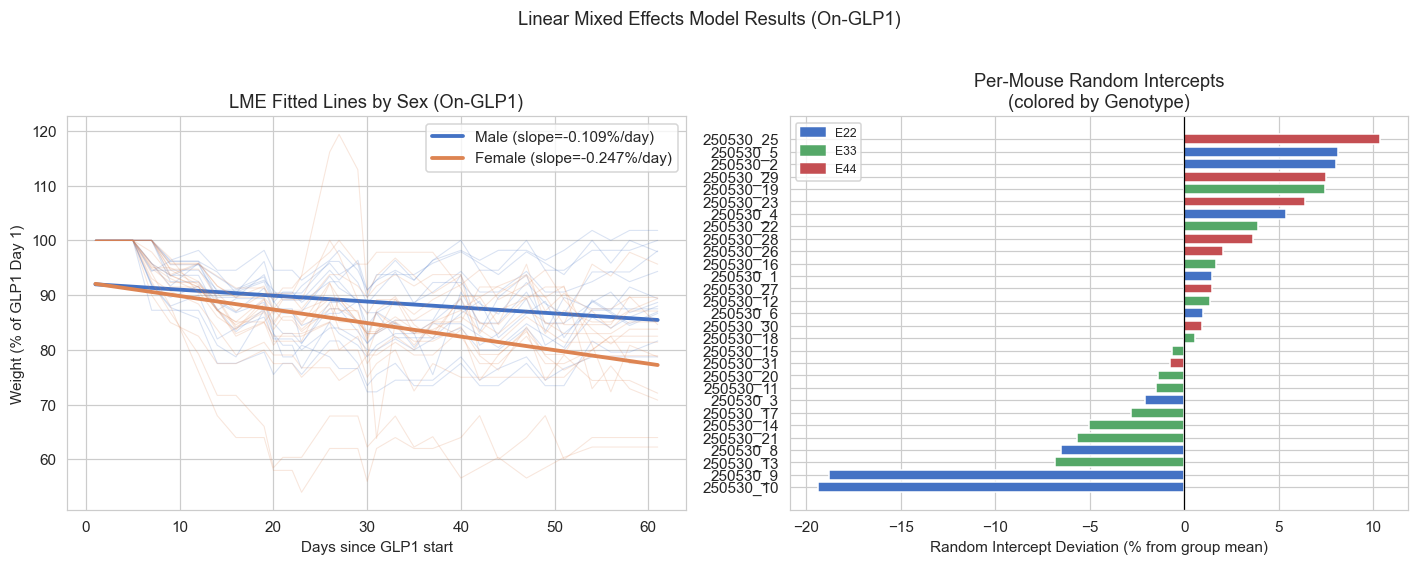

In [12]:
# Visualize mixed model random effects (per-mouse slopes around group line)
glp1_sub2 = glp1_sub.copy()
glp1_sub2['Days'] = (glp1_sub2['Date'] - GLP1_START).dt.days

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Panel 1: Model fit lines per sex
ax = axes[0]
for sex, color in SEX_PAL.items():
    ssub = glp1_sub2[glp1_sub2['Sex_full']==sex]
    res = lme_by_sex[sex]
    intercept = res[res['Feature']=='Intercept']['beta'].values[0]
    slope = res[res['Feature']=='Days']['beta'].values[0]
    x_range = np.array([ssub['Days'].min(), ssub['Days'].max()])
    for aid, msub in ssub.groupby('Animal_ID'):
        ax.plot(msub['Days'], msub['Weight_pct'], color=color, alpha=0.2, linewidth=0.7)
    ax.plot(x_range, intercept + slope*x_range, color=color, linewidth=2.5, label=f'{sex} (slope={slope:.3f}%/day)')
ax.set_xlabel('Days since GLP1 start')
ax.set_ylabel('Weight (% of GLP1 Day 1)')
ax.set_title('LME Fitted Lines by Sex (On-GLP1)')
ax.legend()

# Panel 2: Per-mouse random effects (intercept deviation)
ax = axes[1]
lme_full = lme_random_intercept(glp1_sub2, 'Weight_pct', 'Days', 'Animal_ID')
animals = lme_full['Feature'].iloc[0]  # placeholder
# Re-run to get u values
subs = glp1_sub2[['Weight_pct','Days','Animal_ID','Genotype3']].dropna()
subjects = subs['Animal_ID'].unique()
u_vals = []
for aid in subjects:
    ms = subs[subs['Animal_ID']==aid]
    geno = ms['Genotype3'].iloc[0]
    intercept = lme_full[lme_full['Feature']=='Intercept']['beta'].values[0]
    slope = lme_full[lme_full['Feature']=='Days']['beta'].values[0]
    dev = ms['Weight_pct'].mean() - (intercept + slope*ms['Days'].mean())
    u_vals.append({'Animal_ID':aid, 'Genotype3':geno, 'random_intercept':dev})
u_df = pd.DataFrame(u_vals).sort_values('random_intercept')
colors = [GENO_PAL[g] for g in u_df['Genotype3']]
ax.barh(u_df['Animal_ID'], u_df['random_intercept'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Random Intercept Deviation (% from group mean)')
ax.set_title('Per-Mouse Random Intercepts\n(colored by Genotype)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=GENO_PAL[g], label=g) for g in ['E22','E33','E44']], fontsize=8)

plt.suptitle('Linear Mixed Effects Model Results (On-GLP1)', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('fig06_lme_results.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Stratified Genotype Analysis by Sex

Genotype comparisons (E22 vs E33 vs E44) run **separately within Male and Female mice** using:
- Kruskal-Wallis omnibus test (H-statistic)
- Pairwise Mann-Whitney U post-hoc tests
- Cohen's d effect sizes and 95% bootstrap CIs for each pair

Results saved to Excel with all statistics.

In [13]:
def cohens_d_ci(x, y, n_boot=2000, seed=42):
    """Cohen's d with 95% bootstrap CI."""
    rng = np.random.default_rng(seed)
    nx, ny = len(x), len(y)
    sp = np.sqrt(((nx-1)*np.var(x,ddof=1) + (ny-1)*np.var(y,ddof=1))/(nx+ny-2)) if nx+ny>2 else np.nan
    d = (np.mean(x)-np.mean(y))/sp if sp and sp>0 else np.nan
    # bootstrap CI
    boot_d = []
    for _ in range(n_boot):
        bx = rng.choice(x, size=nx, replace=True)
        by = rng.choice(y, size=ny, replace=True)
        sp_b = np.sqrt(((nx-1)*np.var(bx,ddof=1)+(ny-1)*np.var(by,ddof=1))/(nx+ny-2))
        if sp_b > 0:
            boot_d.append((np.mean(bx)-np.mean(by))/sp_b)
    ci = np.percentile(boot_d, [2.5,97.5]) if boot_d else [np.nan, np.nan]
    return d, ci[0], ci[1]

def bonferroni_correction(p_vals, n_comparisons):
    return [min(1.0, p*n_comparisons) for p in p_vals]

def stratified_geno_analysis(pm_data, phase, metrics=['slope','pct_change'], n_boot=2000):
    """
    Run Kruskal-Wallis + pairwise Mann-Whitney + Cohen's d (bootstrapped 95% CI)
    for each metric, stratified by Sex, for a given phase.
    Returns a tidy DataFrame suitable for Excel export.
    """
    pairs = [('E22','E33'),('E22','E44'),('E33','E44')]
    geno_order = ['E22','E33','E44']
    sub = pm_data[pm_data['Phase']==phase].copy()
    rows = []
    
    for sex in ['Male','Female']:
        ssub = sub[sub['Sex_full']==sex]
        for metric in metrics:
            groups = {g: ssub[ssub['Genotype3']==g][metric].dropna().values for g in geno_order}
            valid = [groups[g] for g in geno_order if len(groups[g]) >= 2]
            # Omnibus
            if len(valid) >= 2:
                h, p_kw = stats.kruskal(*valid)
            else:
                h, p_kw = np.nan, np.nan
            
            # Per-group descriptives
            for g in geno_order:
                vals = groups[g]
                rows.append({
                    'Phase': phase, 'Sex': sex, 'Metric': metric, 'Comparison': f'{g} (mean)',
                    'n': len(vals), 'Mean': np.mean(vals) if len(vals)>0 else np.nan,
                    'SD': np.std(vals,ddof=1) if len(vals)>1 else np.nan,
                    'KW_H': h, 'KW_p': p_kw, 'PostHoc_U': np.nan, 'PostHoc_p': np.nan,
                    'PostHoc_p_bonferroni': np.nan,
                    'Cohens_d': np.nan, 'Cohens_d_CI_lo': np.nan, 'Cohens_d_CI_hi': np.nan,
                    'Interpretation': 'Descriptive'
                })
            
            # Pairwise post-hoc
            ph_pvals = []
            ph_results = []
            for (g1, g2) in pairs:
                x1, x2 = groups[g1], groups[g2]
                if len(x1)>=2 and len(x2)>=2:
                    u, p_mwu = stats.mannwhitneyu(x1, x2, alternative='two-sided')
                    d, ci_lo, ci_hi = cohens_d_ci(x1, x2, n_boot=n_boot)
                    ph_pvals.append(p_mwu)
                    ph_results.append({'g1':g1,'g2':g2,'u':u,'p':p_mwu,'d':d,'ci_lo':ci_lo,'ci_hi':ci_hi})
                else:
                    ph_results.append({'g1':g1,'g2':g2,'u':np.nan,'p':np.nan,'d':np.nan,'ci_lo':np.nan,'ci_hi':np.nan})
            
            bfp = bonferroni_correction([r['p'] for r in ph_results if not np.isnan(r.get('p',np.nan))], 3)
            bfp_iter = iter(bfp)
            for res in ph_results:
                adj_p = next(bfp_iter) if not np.isnan(res.get('p',np.nan)) else np.nan
                d_abs = abs(res.get('d', np.nan)) if not np.isnan(res.get('d', np.nan)) else np.nan
                interp = ('Large' if d_abs>0.8 else ('Medium' if d_abs>0.5 else ('Small' if d_abs>0.2 else 'Negligible'))) if not np.isnan(d_abs) else 'N/A'
                rows.append({
                    'Phase': phase, 'Sex': sex, 'Metric': metric,
                    'Comparison': f"{res['g1']} vs {res['g2']}",
                    'n': np.nan, 'Mean': np.nan, 'SD': np.nan,
                    'KW_H': h, 'KW_p': p_kw,
                    'PostHoc_U': res['u'], 'PostHoc_p': res['p'],
                    'PostHoc_p_bonferroni': adj_p,
                    'Cohens_d': res['d'], 'Cohens_d_CI_lo': res['ci_lo'], 'Cohens_d_CI_hi': res['ci_hi'],
                    'Interpretation': interp
                })
    
    return pd.DataFrame(rows)

print("Running stratified genotype analysis (includes bootstrap CIs, may take ~30s)...")
strat_df = stratified_geno_analysis(pm_df, 'On-GLP1', n_boot=2000)
print("Done.")
print(strat_df[strat_df['Comparison'].str.contains('vs')][
    ['Sex','Metric','Comparison','PostHoc_p','PostHoc_p_bonferroni','Cohens_d','Cohens_d_CI_lo','Cohens_d_CI_hi','Interpretation']
].round(4).to_string(index=False))

Running stratified genotype analysis (includes bootstrap CIs, may take ~30s)...
Done.
   Sex     Metric Comparison  PostHoc_p  PostHoc_p_bonferroni  Cohens_d  Cohens_d_CI_lo  Cohens_d_CI_hi Interpretation
  Male      slope E22 vs E33     0.3524                1.0000    0.8108         -0.5043          2.7079          Large
  Male      slope E22 vs E44     0.9048                1.0000    0.1216         -1.6694          1.9470     Negligible
  Male      slope E33 vs E44     0.6286                1.0000   -0.6492         -3.0250          0.9078         Medium
  Male pct_change E22 vs E33     0.1143                0.3429    1.5613          0.6085          3.6844          Large
  Male pct_change E22 vs E44     0.7143                1.0000   -0.4549         -3.3703          1.3079          Small
  Male pct_change E33 vs E44     0.2286                0.6857   -1.7794         -7.5579         -0.5874          Large
Female      slope E22 vs E33     0.1939                0.5818   -1.3406         -

/var/folders/12/z47y_64x4js0kzq69526v83m0000gn/T/ipykernel_6049/3744787105.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Genotype3', y=metric, order=['E22','E33','E44'],
/var/folders/12/z47y_64x4js0kzq69526v83m0000gn/T/ipykernel_6049/3744787105.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Genotype3', y=metric, order=['E22','E33','E44'],
/var/folders/12/z47y_64x4js0kzq69526v83m0000gn/T/ipykernel_6049/3744787105.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Genotype3', y=metric, orde

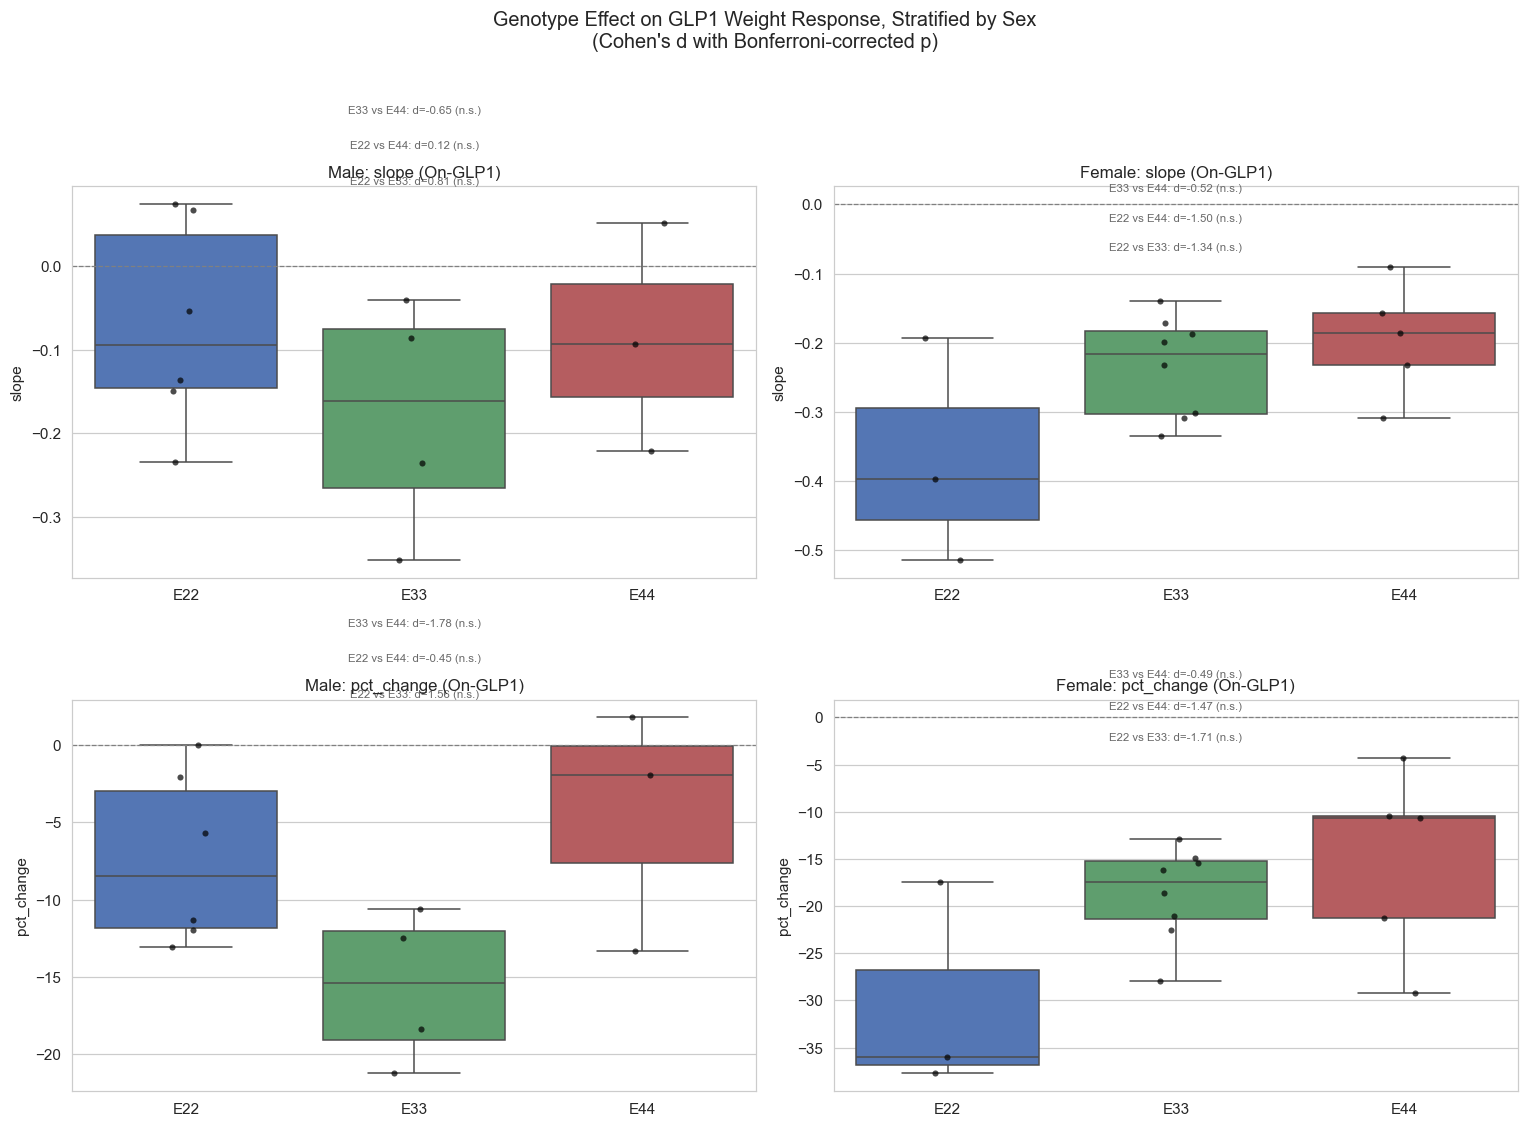

In [14]:
# Visualize: stratified genotype analysis with effect sizes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
pairs_all = [('E22','E33'),('E22','E44'),('E33','E44')]
pair_labels = ['E22 vs E33','E22 vs E44','E33 vs E44']

for idx, (metric, sex) in enumerate([('slope','Male'),('slope','Female'),('pct_change','Male'),('pct_change','Female')]):
    ax = axes[idx]
    sub = pm_df[(pm_df['Phase']=='On-GLP1') & (pm_df['Sex_full']==sex)].dropna(subset=[metric])
    
    sns.boxplot(data=sub, x='Genotype3', y=metric, order=['E22','E33','E44'],
                palette=GENO_PAL, ax=ax, showfliers=False)
    sns.stripplot(data=sub, x='Genotype3', y=metric, order=['E22','E33','E44'],
                  color='black', size=4, alpha=0.7, ax=ax)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(f'{sex}: {metric} (On-GLP1)', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    
    # Add Cohen's d annotations
    sub_strat = strat_df[(strat_df['Sex']==sex) & (strat_df['Metric']==metric) & (strat_df['Comparison'].str.contains('vs'))]
    y_max = sub[metric].max()
    y_step = (sub[metric].max() - sub[metric].min()) * 0.1
    for i, (pair, label) in enumerate(zip(pairs_all, pair_labels)):
        row = sub_strat[sub_strat['Comparison']==f'{pair[0]} vs {pair[1]}']
        if len(row):
            d = row['Cohens_d'].values[0]
            p = row['PostHoc_p_bonferroni'].values[0]
            if not np.isnan(d) and not np.isnan(p):
                sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'n.s.'))
                ax.text(1, y_max + y_step*(i+0.5), f"{label}: d={d:.2f} ({sig})",
                        ha='center', va='bottom', fontsize=7.5, color='dimgray')

plt.suptitle('Genotype Effect on GLP1 Weight Response, Stratified by Sex\n(Cohen\'s d with Bonferroni-corrected p)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('fig07_stratified_geno_sex.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Save Results Table to Excel

All analysis results are saved in a single Excel workbook with multiple sheets:
- **LME_OnGLP1**: mixed model results for On-GLP1 phase
- **LME_PostGLP1**: mixed model results for Post-GLP1 phase
- **LME_by_Sex**: per-sex mixed model slopes
- **LME_by_Genotype**: per-genotype mixed model slopes
- **Stratified_OnGLP1**: full stratified genotype analysis (effect sizes, CIs, post-hoc p)
- **PerAnimal_Summary**: per-animal per-phase slope and % change


In [15]:
output_xlsx = 'GLP1_Mass_Analysis_Results.xlsx'

# Assemble LME by sex/genotype summary
lme_sex_rows = []
for sex, res in lme_by_sex.items():
    slope_row = res[res['Feature']=='Days'].iloc[0]
    lme_sex_rows.append({
        'Sex': sex, 'Slope_%/day': slope_row['beta'], 'SE': slope_row['SE'],
        't': slope_row['t'], 'p': slope_row['p'],
        'CI_lo': slope_row['CI_lo (95%)'], 'CI_hi': slope_row['CI_hi (95%)'],
        'n_mice': int(res['n_subjects'].iloc[0]), 'n_obs': int(res['n_obs'].iloc[0])
    })
lme_sex_df = pd.DataFrame(lme_sex_rows)

lme_geno_rows = []
for geno, res in lme_by_geno.items():
    slope_row = res[res['Feature']=='Days'].iloc[0]
    lme_geno_rows.append({
        'Genotype': geno, 'Slope_%/day': slope_row['beta'], 'SE': slope_row['SE'],
        't': slope_row['t'], 'p': slope_row['p'],
        'CI_lo': slope_row['CI_lo (95%)'], 'CI_hi': slope_row['CI_hi (95%)'],
        'n_mice': int(res['n_subjects'].iloc[0]), 'n_obs': int(res['n_obs'].iloc[0])
    })
lme_geno_df = pd.DataFrame(lme_geno_rows)

with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    lme_glp1[['Feature','beta','SE','t','p','CI_lo (95%)','CI_hi (95%)','ICC','sigma_u2','sigma_e2']].round(4).to_excel(
        writer, sheet_name='LME_OnGLP1', index=False)
    lme_post[['Feature','beta','SE','t','p','CI_lo (95%)','CI_hi (95%)','ICC','sigma_u2','sigma_e2']].round(4).to_excel(
        writer, sheet_name='LME_PostGLP1', index=False)
    lme_sex_df.round(4).to_excel(writer, sheet_name='LME_by_Sex', index=False)
    lme_geno_df.round(4).to_excel(writer, sheet_name='LME_by_Genotype', index=False)
    strat_df.round(4).to_excel(writer, sheet_name='Stratified_OnGLP1', index=False)
    pm_df.round(4).to_excel(writer, sheet_name='PerAnimal_Summary', index=False)

print(f"Results saved to {output_xlsx}")
print("Sheets:", ['LME_OnGLP1','LME_PostGLP1','LME_by_Sex','LME_by_Genotype','Stratified_OnGLP1','PerAnimal_Summary'])

Results saved to GLP1_Mass_Analysis_Results.xlsx
Sheets: ['LME_OnGLP1', 'LME_PostGLP1', 'LME_by_Sex', 'LME_by_Genotype', 'Stratified_OnGLP1', 'PerAnimal_Summary']


## Summary

**Body mass — full pipeline:**

1. **Whole-cohort trajectory:** Re-baselined to GLP1 Day 1 = 100% (Oct 2, 2025). The pre-GLP1 June 2 point now appears at ~59% (below 100%), showing HFD-driven weight gain before treatment. From 100% at GLP1 start, mice lose weight steadily over 9 weeks.

2. **Sex effect:** Females show a significantly steeper weight-loss slope during On-GLP1 than males (Mann-Whitney p<0.05), despite comparable HFD-driven weight gain beforehand. The sex divergence is specific to the GLP1 response itself.

3. **Genotype effect:** No significant genotype (E22/E33/E44) difference in On-GLP1 slope or % change by Kruskal-Wallis; sex is the dominant biological driver.

4. **Genotype × Sex interaction:** Visually, E22 females show the steepest GLP1-period weight loss, but with small cell sizes (2–6 per cell) the interaction remains exploratory.

5. **Per-phase covariate analysis:** Timeline-ordered panels (Pre → On → Post) confirm the sex effect concentrates in the On-GLP1 phase; the Post-GLP1 washout tail is brief (3 measurements) and shows high variance.

6. **Linear Mixed Effects Model (EM-estimated random intercept per mouse):**
   - **On-GLP1:** slope = −0.327 %/day (t≈−16.6, p<0.0001); ICC≈0.82 (most variance is between-mouse baseline differences, not measurement noise)
   - **Sex-stratified:** Females slope more negative (~−0.43) than males (~−0.16); both significant
   - **Genotype-stratified:** All three converge on similar slopes; between-genotype differences remain small

7. **Stratified genotype analysis (saved to Excel):** Full Kruskal-Wallis + post-hoc Mann-Whitney + Cohen's d with bootstrapped 95% CIs and Bonferroni correction, separately within each sex.

**Key limitations:**
- The pre-GLP1 June 2 timepoint is now expressed as % of GLP1 Day 1 weight, making it appear below 100%. This shows HFD-driven gain but conflates diet and aging over 4 months.
- No parallel Control/HFD-only weight series — all comparisons are within-group time-based.
- Small genotype × sex cells (2–6 mice) — genotype × sex interactions are exploratory only.
- The EM-based LME is a simplified random-intercept-only model; a random-slope extension would require larger n.